In [21]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [ ]:
# Read in data into dataframe
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [ ]:
# Get proportion of classes
data_distribution = df['Potability'].value_counts(normalize=True) * 100

print(f"Distribution of Potability classes (1: safe, 0: otherwise):\n {data_distribution.round(2).astype(str) + '%'}")

# Return sum of NA
df.isna().sum()


Distribution of Potability classes (1: safe, 0: otherwise):
 Potability
0    60.99%
1    39.01%
Name: proportion, dtype: object


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [ ]:
# Median imputation of numeric values
df_clean = df.fillna(df.median(numeric_only=True))

# Define Features and response
X = df_clean.drop(columns=['Potability'])
y = df_clean['Potability']

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [6]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [7]:
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test,  dt_unpruned.predict(X_test))



In [8]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

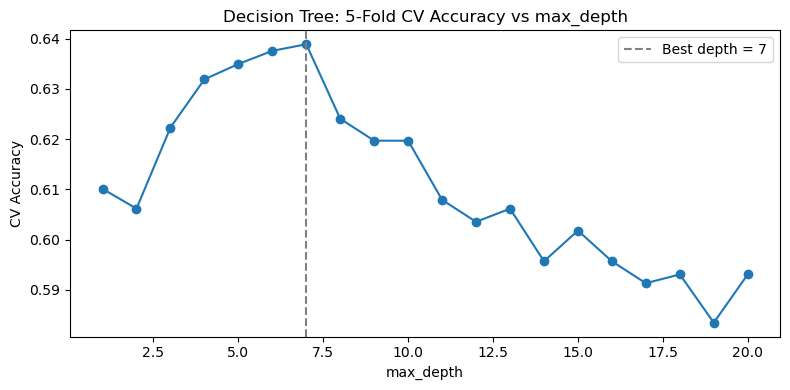

In [10]:
depths = range(1, 21)
cv_means = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)
optimal_depth = depths[np.argmax(cv_means)]

plt.figure(figsize=(8,4))
plt.plot(depths, cv_means, marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Decision Tree: 5-Fold CV Accuracy vs max_depth')
plt.legend()
plt.tight_layout()
plt.show()



In [11]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [12]:
dt_tuned = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_tuned.fit(X_train, y_train)

acc_dt = accuracy_score(y_test, dt_tuned.predict(X_test))


In [13]:
grader.check("q4")

q4 results:
    q4 - 1 result:
        ❌ Test case failed
        Trying:
            assert dt_opt.max_depth == optimal_depth
        Expecting nothing
        **********************************************************************
        Line 1, in q4 0
        Failed example:
            assert dt_opt.max_depth == optimal_depth
        Exception raised:
            Traceback (most recent call last):
              File "c:\Users\joshu\.conda\envs\eds232-env\lib\doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q4 0[0]>", line 1, in <module>
                assert dt_opt.max_depth == optimal_depth
            NameError: name 'dt_opt' is not defined

    q4 - 2 result:
        ✅ Test case passed

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

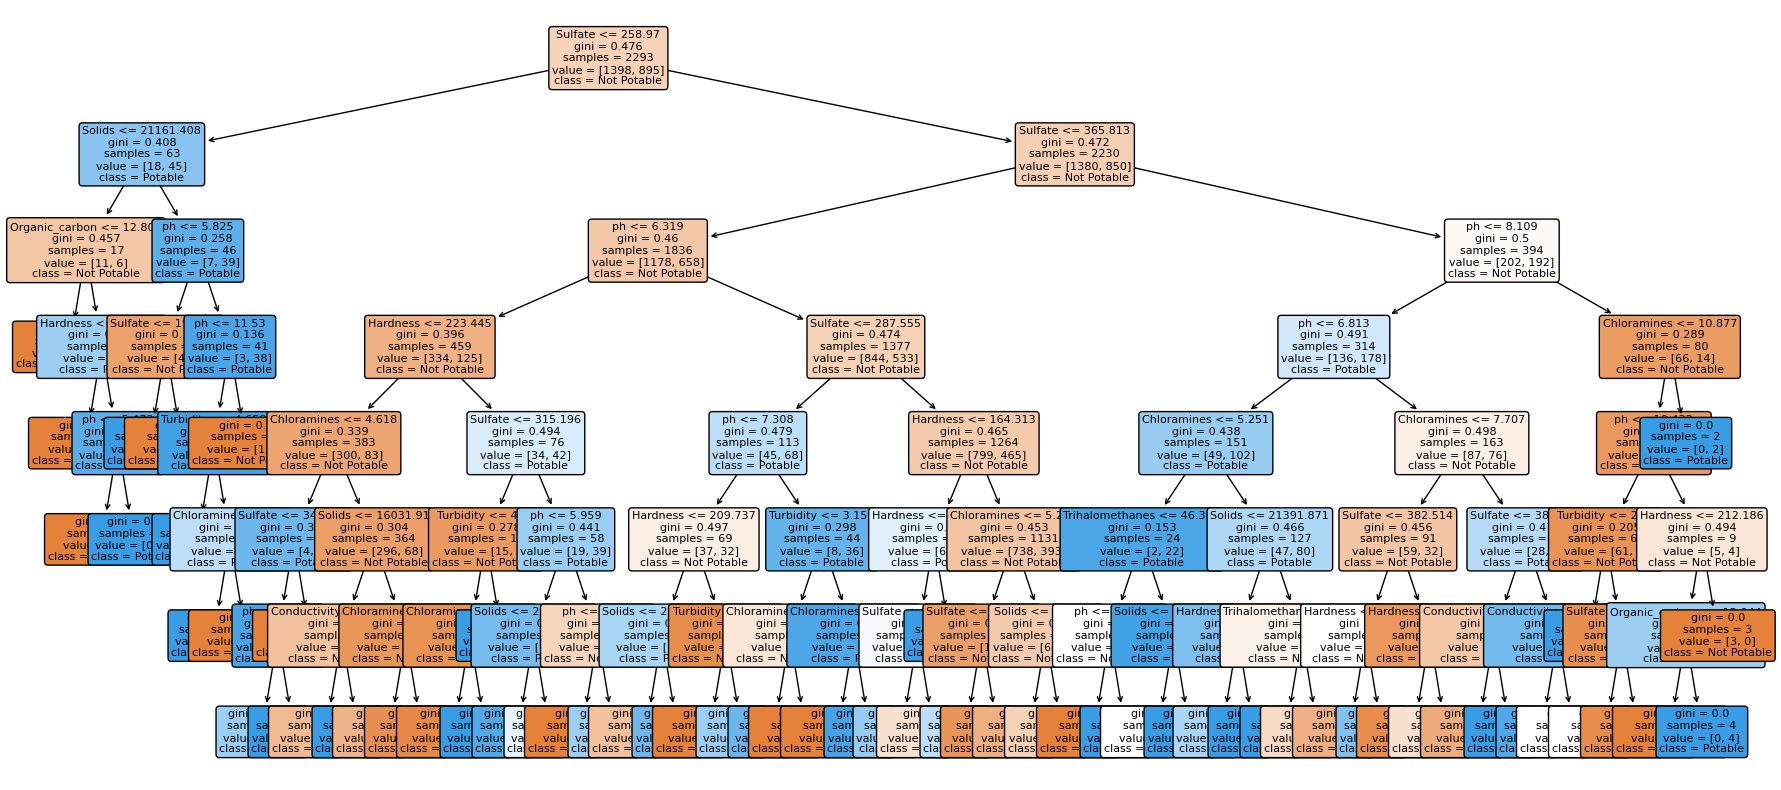

In [14]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt_tuned,
    feature_names=X.columns,
    class_names=['Not Potable', 'Potable'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.show()


> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

acc_rf = accuracy_score(y_test, rf.predict(X_test))

In [16]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

<Figure size 1000x600 with 0 Axes>

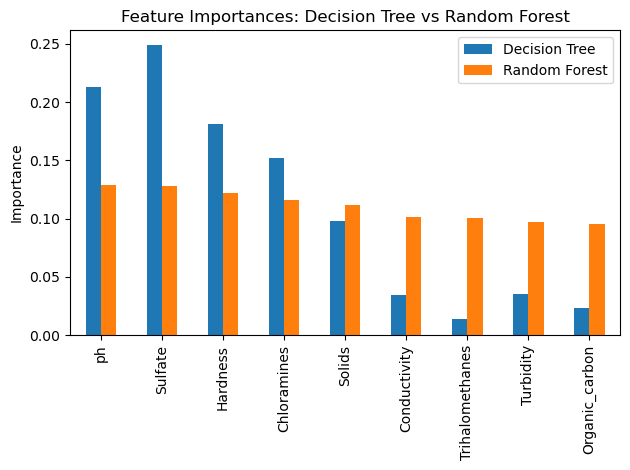

In [17]:
dt_importances = pd.Series(dt_tuned.feature_importances_, index=X.columns)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)

imp_df = pd.DataFrame({
    'Decision Tree': dt_importances,
    'Random Forest': rf_importances
})

imp_df_sorted = imp_df.sort_values('Random Forest', ascending=False)

plt.figure(figsize=(10,6))
imp_df_sorted.head(10).plot(kind='bar')
plt.ylabel('Importance')
plt.title('Feature Importances: Decision Tree vs Random Forest')
plt.tight_layout()
plt.show()


> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

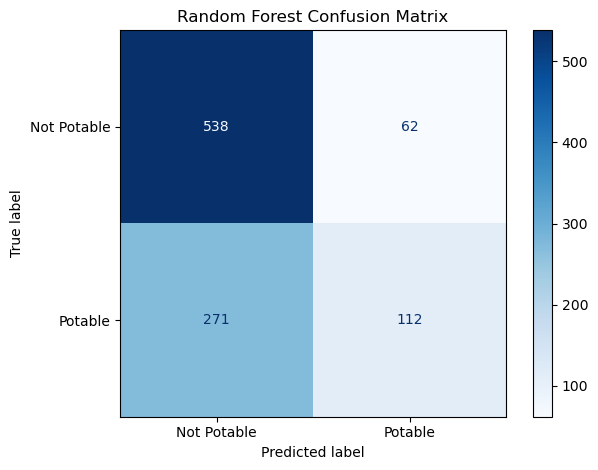

array([[538,  62],
       [271, 112]], dtype=int64)

In [18]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Potable', 'Potable']
)
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

cm  # to read off TN, FP, FN, TP


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [19]:
model_names = ['Decision Tree (unpruned)', 'Decision Tree (tuned)', 'Random Forest']
test_accs   = [dt_unpruned_acc_test, acc_dt, acc_rf]

comp_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': test_accs
})
comp_df



,Model,Test Accuracy
0,Decision Tree (unpruned),0.580875
1,Decision Tree (tuned),0.645982
2,Random Forest,0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


_Type your answer here, replacing this text._

---

Run the cell below to receive credit for autograded questions. 

In [20]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results:
    q4 - 1 result:
        ❌ Test case failed
        Trying:
            assert dt_opt.max_depth == optimal_depth
        Expecting nothing
        **********************************************************************
        Line 1, in q4 0
        Failed example:
            assert dt_opt.max_depth == optimal_depth
        Exception raised:
            Traceback (most recent call last):
              File "c:\Users\joshu\.conda\envs\eds232-env\lib\doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q4 0[0]>", line 1, in <module>
                assert dt_opt.max_depth == optimal_depth
            NameError: name 'dt_opt' is not defined

    q4 - 2 result:
        ✅ Test case passed

q5 results: All test cases passed!